# Textual Contextual Bandits with Moderation Data


---

## Problem setting

You are supposed to design a moderation decision policy for user-generated text. For each post, the system must choose one action:

| Action id | Action | Operational meaning |
|---:|---|---|
| 0 | `allow` | publish immediately |
| 1 | `review` | route to human moderation |
| 2 | `block` | automatically remove |

You only observe the reward of the action you chose. This is contextual bandit feedback, not supervised full-information learning.

---
## Important note on running

This notebook requires internet access the first time it downloads the Hugging Face datasets. After caching, it can be rerun offline on the same machine.

Install dependencies:

```bash
pip install numpy pandas matplotlib torch datasets tqdm
```

**Name:** Narges Kari

**Student ID:** 402110821

**Course:** Deep Reinforcement Learning (Spring 2026)

**Instructor:** Prof. Mohammad Hossein Rohban

In [1]:
import math
import re
import hashlib
import random
import warnings
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, List, Optional, Tuple
from pathlib import Path
import urllib.request
import time

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# 1. local CSV cache,
# 2. official TweetEval GitHub raw files,
# 3. Hugging Face datasets,
# 4. original-repo prepared memmaps if available.
try:
    from datasets import load_dataset
except Exception:
    load_dataset = None

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ACTIONS = ["allow", "review", "block"]
ALLOW, REVIEW, BLOCK = 0, 1, 2
N_ACTIONS = len(ACTIONS)

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

Device: cpu


In [4]:
@dataclass
class Config:
    base_dataset_name: str = "cardiffnlp/tweet_eval"
    base_dataset_config: str = "offensive"

    ood_dataset_name: str = "cardiffnlp/tweet_eval"
    ood_dataset_config: str = "hate"

    # Keep these modest for CPU labs. Increase for stronger results.
    n_logged: int = 6000
    n_eval: int = 2000
    n_ood: int = 2000

    # Hashing vectorizer
    hash_dim: int = 1024
    min_token_len: int = 2

    # Neural reward model
    hidden: int = 128
    dropout_p: float = 0.2
    batch_size: int = 64
    reward_epochs: int = 15
    ensemble_epochs: int = 15
    risk_epochs: int = 15
    lr: float = 1e-3
    weight_decay: float = 1e-4

    # Logging policy
    behavior_temperature: float = 0.5
    behavior_uniform_mix: float = 0.10

    # Policies
    epsilon: float = 0.15
    ensemble_size: int = 5
    mc_samples: int = 20

    # Safe exploration
    unsafe_threshold: float = 0.40
    extreme_unsafe_threshold: float = 0.75
    safety_margin: float = 0.05

    # LinUCB and NeuralUCB
    linucb_alpha: float = 0.4
    linucb_l2: float = 1.0
    neuralucb_alpha: float = 0.2
    neural_feature_dim: int = 128

    

cfg = Config()
cfg

Config(base_dataset_name='cardiffnlp/tweet_eval', base_dataset_config='offensive', ood_dataset_name='cardiffnlp/tweet_eval', ood_dataset_config='hate', n_logged=6000, n_eval=2000, n_ood=2000, hash_dim=1024, min_token_len=2, hidden=128, dropout_p=0.2, batch_size=64, reward_epochs=15, ensemble_epochs=15, risk_epochs=15, lr=0.001, weight_decay=0.0001, behavior_temperature=0.5, behavior_uniform_mix=0.1, epsilon=0.15, ensemble_size=5, mc_samples=20, unsafe_threshold=0.4, extreme_unsafe_threshold=0.75, safety_margin=0.05, linucb_alpha=0.4, linucb_l2=1.0, neuralucb_alpha=0.2, neural_feature_dim=128)

## 1. Real dataset loading
### Task 1

Run the loader and inspect examples.

In [5]:
CACHE_DIR = Path("./tweeteval_cache")
CACHE_DIR.mkdir(exist_ok=True)

TWEETEVAL_GITHUB_BASE = "https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets"

# GitHub uses val, while Hugging Face commonly calls this validation.
SPLIT_TO_GITHUB = {
    "train": "train",
    "validation": "val",
    "val": "val",
    "test": "test",
}

def _sample_or_all(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df) <= n:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

def _read_cached_csv(task: str, split: str) -> Optional[pd.DataFrame]:
    path = CACHE_DIR / f"tweeteval_{task}_{split}.csv"
    if path.exists():
        df = pd.read_csv(path)
        if {"text", "label"}.issubset(df.columns):
            df["label"] = df["label"].astype(int)
            df["source"] = f"local_cache/{path.name}"
            return df
    return None

def _write_cached_csv(df: pd.DataFrame, task: str, split: str) -> None:
    path = CACHE_DIR / f"tweeteval_{task}_{split}.csv"
    df[["text", "label", "source"]].to_csv(path, index=False)

def _download_text(url: str, timeout: int = 30, retries: int = 4) -> str:
    last_error = None
    for attempt in range(retries):
        try:
            req = urllib.request.Request(
                url,
                headers={
                    "User-Agent": "Mozilla/5.0 educational-notebook",
                    "Accept": "text/plain,*/*",
                },
            )
            with urllib.request.urlopen(req, timeout=timeout) as response:
                return response.read().decode("utf-8", errors="replace")
        except Exception as e:
            last_error = e
            sleep_s = min(2 ** attempt, 8)
            print(f"Download failed attempt {attempt+1}/{retries}: {url}\n  {type(e).__name__}: {e}\n  retrying in {sleep_s}s")
            time.sleep(sleep_s)
    raise RuntimeError(f"Could not download {url}: {last_error}")

def load_tweeteval_from_github(task: str, split: str) -> pd.DataFrame:
    """Load official TweetEval text/label files directly from GitHub raw.
    Labels are stored as a single whitespace-separated line in the official repo.
    Text files contain one tweet per line.
    """
    cached = _read_cached_csv(task, split)
    if cached is not None:
        return cached

    gh_split = SPLIT_TO_GITHUB[split]
    text_url = f"{TWEETEVAL_GITHUB_BASE}/{task}/{gh_split}_text.txt"
    label_url = f"{TWEETEVAL_GITHUB_BASE}/{task}/{gh_split}_labels.txt"

    print(f"Downloading TweetEval {task}/{split} from official GitHub raw files.")
    text_raw = _download_text(text_url)
    label_raw = _download_text(label_url)

    texts = [line.strip() for line in text_raw.splitlines()]
    labels = [int(x) for x in label_raw.split()]

    if len(texts) != len(labels):
        raise ValueError(
            f"Text/label length mismatch for {task}/{split}: "
            f"{len(texts)} texts vs {len(labels)} labels"
        )

    df = pd.DataFrame({"text": texts, "label": labels})
    df["label"] = df["label"].astype(int)
    df["source"] = f"github_raw/tweeteval/{task}/{split}"
    _write_cached_csv(df, task, split)
    return df

def load_tweeteval_from_hf(dataset_name: str, config_name: str, split: str) -> pd.DataFrame:
    if load_dataset is None:
        raise RuntimeError("datasets is not installed; skipping Hugging Face fallback.")
    ds = load_dataset(dataset_name, config_name, split=split)
    df = pd.DataFrame(ds)
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"Expected text and label columns, got {df.columns.tolist()}")
    df = df[["text", "label"]].copy()
    df["label"] = df["label"].astype(int)
    df["source"] = f"huggingface/{dataset_name}/{config_name}/{split}"
    return df

def load_original_repo_memmap(task: str, split_hint: str = "train") -> pd.DataFrame:
    """Fallback for users who already ran the original repo's prepare_data.py.

    The original repo stores GPT-2 token ids and labels in hf_data/tweet_eval/{task}.
    This fallback creates pseudo-text from token ids so the rest of the notebook can
    still run without Hugging Face/GitHub. Prefer GitHub/HF because they preserve text.
    """
    possible_roots = [
        Path("hf_data") / "tweet_eval" / task,
        Path("./llm-bandit-main") / "hf_data" / "tweet_eval" / task,
        Path("../llm-bandit-main") / "hf_data" / "tweet_eval" / task,
        Path("/mnt/data/llm-bandit-main") / "hf_data" / "tweet_eval" / task,
    ]
    root = next((p for p in possible_roots if (p / "data_labels.bin").exists()), None)
    if root is None:
        raise FileNotFoundError(f"No original repo memmap found for task={task}")

    block_size = 64
    labels = np.memmap(root / "data_labels.bin", dtype=np.uint16, mode="r")
    text_ids = np.memmap(root / "data_text.bin", dtype=np.uint16, mode="r").reshape(-1, block_size)

    pseudo_texts = []
    for row in text_ids:
        toks = [f"tok_{int(x)}" for x in row if int(x) != 0]
        pseudo_texts.append(" ".join(toks[:80]))

    df = pd.DataFrame({"text": pseudo_texts, "label": labels.astype(int)})
    df["source"] = f"original_repo_memmap/{root}"
    return df

def load_real_tweeteval_task(task: str, split: str, cfg: Config) -> pd.DataFrame:
    """Robust loader that avoids Hugging Face unless needed."""
    try:
        return load_tweeteval_from_github(task, split)
    except Exception as github_error:
        print(f"GitHub raw loading failed for {task}/{split}: {type(github_error).__name__}: {github_error}")

    try:
        return load_tweeteval_from_hf(cfg.base_dataset_name, task, split)
    except Exception as hf_error:
        print(f"Hugging Face fallback failed for {task}/{split}: {type(hf_error).__name__}: {hf_error}")

    try:
        return load_original_repo_memmap(task, split)
    except Exception as memmap_error:
        raise RuntimeError(
            f"All real-data loading methods failed for TweetEval {task}/{split}.\n"
            f"Fix options:\n"
            f"  1. Re-run later; Hugging Face 429 usually clears.\n"
            f"  2. Ensure GitHub raw access is available.\n"
            f"  3. Manually place CSVs in ./tweeteval_cache/ named tweeteval_{task}_{split}.csv "
            f"with columns text,label.\n"
            f"  4. Run the original repo prepare_data.py --data {task} to create hf_data memmaps.\n"
            f"Last memmap error: {type(memmap_error).__name__}: {memmap_error}"
        )

def load_real_moderation_data(cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load real in-domain and out-of-domain moderation datasets robustly."""
    # In-domain offensive data.
    train = load_real_tweeteval_task("offensive", "train", cfg)
    validation = load_real_tweeteval_task("offensive", "validation", cfg)
    test = load_real_tweeteval_task("offensive", "test", cfg)
    eval_pool = pd.concat([validation, test], ignore_index=True)

    # OOD hate data.
    ood_validation = load_real_tweeteval_task("hate", "validation", cfg)
    ood_test = load_real_tweeteval_task("hate", "test", cfg)
    ood_pool = pd.concat([ood_validation, ood_test], ignore_index=True)

    logged = _sample_or_all(train, cfg.n_logged, SEED + 1)
    eval_df = _sample_or_all(eval_pool, cfg.n_eval, SEED + 2)
    ood_df = _sample_or_all(ood_pool, cfg.n_ood, SEED + 3)

    return logged, eval_df, ood_df

logged_raw, eval_raw, ood_raw = load_real_moderation_data(cfg)

print("Loaded real datasets:")
display(pd.DataFrame({
    "split": ["logged_train", "in_domain_eval", "ood_hate_eval"],
    "rows": [len(logged_raw), len(eval_raw), len(ood_raw)],
    "harmful_rate": [logged_raw.label.mean(), eval_raw.label.mean(), ood_raw.label.mean()],
    "source": [logged_raw.source.iloc[0], eval_raw.source.iloc[0], ood_raw.source.iloc[0]],
}))

display(logged_raw.sample(min(10, len(logged_raw)), random_state=SEED))

Loaded real datasets:


,split,rows,harmful_rate,source
0,logged_train,6000,0.331167,local_cache/tweeteval_offensive_train.csv
1,in_domain_eval,2000,0.317000,local_cache/tweeteval_offensive_validation.csv
2,ood_hate_eval,2000,0.424000,local_cache/tweeteval_hate_validation.csv


,text,label,source
4503,@user Antifa thugs remind me of orcs if they a...,1,local_cache/tweeteval_offensive_train.csv
1424,13/? BOOOM. The MAC telling the @user to pay...,0,local_cache/tweeteval_offensive_train.csv
4414,@user That’s why conservatives are so afraid o...,0,local_cache/tweeteval_offensive_train.csv
5914,@user You can’t pretend to care about women wh...,0,local_cache/tweeteval_offensive_train.csv
3768,@user Diversity = Success? LMAO,0,local_cache/tweeteval_offensive_train.csv
5729,@user And when did Breitbart become a reliable...,0,local_cache/tweeteval_offensive_train.csv
1491,. @user @user @user Fake conservatives and the...,1,local_cache/tweeteval_offensive_train.csv
3592,@user @user Insanity...just like the commies! ...,0,local_cache/tweeteval_offensive_train.csv
4378,@user WHAT THE FUCK,1,local_cache/tweeteval_offensive_train.csv
318,@user Strange how Gun Control never works Crim...,0,local_cache/tweeteval_offensive_train.csv


## 2. Text diagnostics and severity proxy

 Real moderation costs often depend on severity, but `tweet_eval/offensive` only provides binary labels.

We therefore construct a **severity proxy** from text signals and the harmful label. This is not perfect and should be discussed critically. It is used only to define richer reward and regret for the bandit environment.

In [6]:

TOKEN_RE = re.compile(r"[A-Za-z_@#!']+")

MILD_RISK_TERMS = {
    "stupid", "idiot", "shut", "hate", "trash", "dumb", "fool", "sucks",
    "worst", "clown", "garbage", "nonsense", "awful", "pathetic"
}

def tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(str(text).lower())

def text_risk_score(text: str) -> float:
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    
    match_count = sum(1 for t in tokens if t in MILD_RISK_TERMS)
    special_matches = sum(1 for t in tokens if t.startswith('#') or t.startswith('@'))
    
    score = (match_count * 1.5 + special_matches * 0.5) / math.sqrt(len(tokens))
    return float(np.clip(score, 0.0, 5.0))

def severity_proxy(text: str, label: int) -> float:
    score = text_risk_score(text)
    base_severity = min(score / 4.0, 0.5)
    
    if label == 1:
        return float(0.5 + base_severity)
    else:
        return float(base_severity)

def add_text_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["tokens"] = df["text"].apply(tokenize)
    df["n_tokens"] = df["tokens"].apply(len)
    df["risk_score"] = df["text"].apply(text_risk_score)
    df["severity"] = df.apply(lambda row: severity_proxy(row["text"], row["label"]), axis=1)
    df["has_risk_terms"] = df["risk_score"] > 0.0
    df["is_long_text"] = df["n_tokens"] > 15
    return df

logged_df = add_text_diagnostics(logged_raw)
eval_df = add_text_diagnostics(eval_raw)
ood_df = add_text_diagnostics(ood_raw)

display(pd.DataFrame({
    "split": ["logged", "in_domain_eval", "ood_hate_eval"],
    "harmful_rate": [logged_df.label.mean(), eval_df.label.mean(), ood_df.label.mean()],
    "mean_risk_score": [logged_df.risk_score.mean(), eval_df.risk_score.mean(), ood_df.risk_score.mean()],
    "mean_severity": [logged_df.severity.mean(), eval_df.severity.mean(), ood_df.severity.mean()],
}))

,split,harmful_rate,mean_risk_score,mean_severity
0,logged,0.331167,0.329964,0.244862
1,in_domain_eval,0.317000,0.334442,0.239212
2,ood_hate_eval,0.424000,0.302564,0.286977


## 3. Reward, oracle, regret, and cost-sensitivity analysis

A moderation classifier predicts a label. A contextual bandit chooses an action.

This section defines three product cost profiles:

1. `balanced`: balanced platform policy.
2. `high_safety`: strict platform; allowing harmful content is extremely costly.
3. `free_expression`: blocking benign content is especially costly.

You must evaluate how the optimal action distribution changes under different cost profiles.

### Task 3

Implement:

- `expected_reward_for_action`
- `reward_table`
- `oracle_action_and_value`
- `expected_regret`
- cost-profile comparison


In [9]:

COST_PROFILES = {
    "balanced": {
        "benign_allow": 1.00,
        "benign_review": 0.30,
        "benign_block": -1.60,
        "harm_allow_base": -2.00,
        "harm_allow_severity": -2.20,
        "harm_review_base": 0.05,
        "harm_review_severity": 0.20,
        "harm_block_base": 0.75,
        "harm_block_severity": 0.55,
    },
    "high_safety": {
        "benign_allow": 0.85,
        "benign_review": 0.20,
        "benign_block": -1.10,
        "harm_allow_base": -3.20,
        "harm_allow_severity": -3.50,
        "harm_review_base": 0.20,
        "harm_review_severity": 0.30,
        "harm_block_base": 1.00,
        "harm_block_severity": 0.85,
    },
    "free_expression": {
        "benign_allow": 1.15,
        "benign_review": 0.15,
        "benign_block": -2.80,
        "harm_allow_base": -1.20,
        "harm_allow_severity": -1.40,
        "harm_review_base": 0.05,
        "harm_review_severity": 0.15,
        "harm_block_base": 0.45,
        "harm_block_severity": 0.35,
    },
}

ACTIVE_PROFILE = "balanced"

def expected_reward_for_action(label: int, severity: float, action: int, profile: str = ACTIVE_PROFILE) -> float:
    p = COST_PROFILES[profile]
    
    if label == 0:
        if action == ALLOW:
            return p["benign_allow"]
        elif action == REVIEW:
            return p["benign_review"]
        elif action == BLOCK:
            return p["benign_block"]
    else:
        if action == ALLOW:
            return p["harm_allow_base"] + p["harm_allow_severity"] * severity
        elif action == REVIEW:
            return p["harm_review_base"] + p["harm_review_severity"] * severity
        elif action == BLOCK:
            return p["harm_block_base"] + p["harm_block_severity"] * severity
            
    return 0.0
def sample_observed_reward(
    label: int,
    severity: float,
    action: int,
    rng: np.random.Generator,
    profile: str = ACTIVE_PROFILE,
    noise_std: float = 0.08,
) -> float:
    return float(expected_reward_for_action(label, severity, action, profile) + rng.normal(0.0, noise_std))

def reward_table(df: pd.DataFrame, profile: str = ACTIVE_PROFILE) -> np.ndarray:
    n = len(df)
    r_matrix = np.zeros((n, N_ACTIONS))
    labels = df["label"].values
    severities = df["severity"].values
    
    for a in range(N_ACTIONS):
        for i in range(n):
            r_matrix[i, a] = expected_reward_for_action(labels[i], severities[i], a, profile)
            
    return r_matrix

def oracle_action_and_value(df: pd.DataFrame, profile: str = ACTIVE_PROFILE) -> Tuple[np.ndarray, np.ndarray]:
    r_matrix = reward_table(df, profile)
    oracle_acts = np.argmax(r_matrix, axis=1)
    oracle_vals = np.max(r_matrix, axis=1)
    return oracle_acts, oracle_vals

def expected_regret(df: pd.DataFrame, actions: np.ndarray, profile: str = ACTIVE_PROFILE) -> np.ndarray:
    _, oracle_vals = oracle_action_and_value(df, profile)
    r_matrix = reward_table(df, profile)
    chosen_rewards = r_matrix[np.arange(len(df)), actions]
    return oracle_vals - chosen_rewards

def summarize_oracle_by_profile(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    summary_rows = []
    for prof in COST_PROFILES.keys():
        acts, vals = oracle_action_and_value(df, prof)
        rates = np.bincount(acts, minlength=N_ACTIONS) / len(df)
        
        summary_rows.append({
            "split": split_name,
            "profile": prof,
            "mean_oracle_value": float(np.mean(vals)),
            "oracle_allow_rate": float(rates[ALLOW]),
            "oracle_review_rate": float(rates[REVIEW]),
            "oracle_block_rate": float(rates[BLOCK]),
        })
    return pd.DataFrame(summary_rows)

oracle_profile_table = pd.concat([
    summarize_oracle_by_profile(logged_df, "logged"),
    summarize_oracle_by_profile(eval_df, "eval"),
    summarize_oracle_by_profile(ood_df, "ood_hate"),
], ignore_index=True)

display(oracle_profile_table)

,split,profile,mean_oracle_value,oracle_allow_rate,oracle_review_rate,oracle_block_rate
0,logged,balanced,1.021429,0.668833,0.0,0.331167
1,logged,high_safety,1.060743,0.668833,0.0,0.331167
2,logged,free_expression,0.984505,0.668833,0.0,0.331167
3,eval,balanced,1.020563,0.683000,0.0,0.317000
4,eval,high_safety,1.051807,0.683000,0.0,0.317000
5,eval,free_expression,0.991617,0.683000,0.0,0.317000
6,ood_hate,balanced,1.026512,0.576000,0.0,0.424000
7,ood_hate,high_safety,1.118391,0.576000,0.0,0.424000
8,ood_hate,free_expression,0.937526,0.576000,0.0,0.424000


## 4. Logged bandit data with propensities

We simulate a behavior policy that resembles a legacy moderation system. It uses text heuristics and randomization.

For each example it logs:

```text
x_i, a_i, r_i, p_i
```

where `p_i = behavior_policy(a_i | x_i)`.

### Task 4

Implement the behavior policy and generate logged bandit data.

In [10]:

def softmax(z: np.ndarray, temperature: float = 1.0) -> np.ndarray:
    z = z / temperature
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

def behavior_action_probs(text: str, cfg: Config = cfg) -> np.ndarray:
    # 1- use text_risk_score
    # 2- convert risk into preferences over allow/review/block
    # 3- softmax with temperature
    # 4- mix with uniform probabilities for support
    risk = text_risk_score(text)
    
    logits = np.array([
        3.0 - 2.0 * risk,
        -1.0 + 1.5 * risk - 0.2 * (risk**2),
        -4.0 + 2.0 * risk
    ])
    
    probs = softmax(logits, cfg.behavior_temperature)
    mix = cfg.behavior_uniform_mix
    
    return (1 - mix) * probs + mix / N_ACTIONS

def make_logged_bandit_data(df: pd.DataFrame, cfg: Config, seed: int = SEED) -> pd.DataFrame:
    # 1- sample logged action from last fucntion
    # 2- observe only reward for chosen action
    # 3- store action, propensity, reward
    rng = np.random.default_rng(seed)
    df_log = df.copy()
    
    actions = []
    propensities = []
    rewards = []
    
    for idx, row in df_log.iterrows():
        probs = behavior_action_probs(row["text"], cfg)
        action = rng.choice(N_ACTIONS, p=probs)
        reward = sample_observed_reward(row["label"], row["severity"], action, rng)
        
        actions.append(action)
        propensities.append(probs[action])
        rewards.append(reward)
        
    df_log["logged_action"] = actions
    df_log["logged_action_name"] = [ACTIONS[a] for a in actions]
    df_log["propensity"] = propensities
    df_log["reward"] = rewards
    
    return df_log

bandit_log = make_logged_bandit_data(logged_df, cfg, seed=SEED + 10)

display(bandit_log.head())
display(bandit_log["logged_action_name"].value_counts(normalize=True).rename("rate").to_frame())
display(bandit_log["propensity"].describe().to_frame())

,text,label,source,tokens,n_tokens,risk_score,severity,has_risk_terms,is_long_text,logged_action,logged_action_name,propensity,reward
0,"@user So funny, this was labeled as sensitive ...",1,local_cache/tweeteval_offensive_train.csv,"[@user, so, funny, this, was, labeled, as, sen...",20,0.111803,0.527951,True,True,0,allow,0.932675,-3.099340
1,@user @user ...I happen to know of your waywar...,0,local_cache/tweeteval_offensive_train.csv,"[@user, @user, i, happen, to, know, of, your, ...",48,0.144338,0.036084,True,True,0,allow,0.932509,0.913426
2,@user @user He/she deserves those tattoos. Hop...,0,local_cache/tweeteval_offensive_train.csv,"[@user, @user, he, she, deserves, those, tatto...",11,0.301511,0.075378,True,False,1,review,0.035730,0.286547
3,@user But gun control,0,local_cache/tweeteval_offensive_train.csv,"[@user, but, gun, control]",4,0.250000,0.062500,True,False,0,allow,0.931636,1.089645
4,@user He is hurt and no one has checked on him!!!,1,local_cache/tweeteval_offensive_train.csv,"[@user, he, is, hurt, and, no, one, has, check...",11,0.150756,0.537689,True,False,0,allow,0.932472,-3.285287


,rate
logged_action_name,
allow,0.892333
review,0.061333
block,0.046333


,propensity
count,6000.000000
mean,0.845762
std,0.246235
min,0.033334
25%,0.927411
50%,0.931915
75%,0.932541
max,0.933031


## 5. Hashing text features
We are going to use a deteministic hashing vectorizer, which is weaker than larger models like GPT, yet is still handy with real text and supports the contextual-bandit methods.

### Task 5

Implement a hashing vectorizer.


In [11]:

def stable_hash(token: str, dim: int) -> int:
    val = int(hashlib.md5(token.encode('utf-8')).hexdigest(), 16)
    return val % dim

def stable_sign(token: str) -> int:
    val = int(hashlib.sha1(token.encode('utf-8')).hexdigest(), 16)
    return 1 if (val % 2) == 1 else -1

def hashing_vectorize(texts: Iterable[str], dim: int = cfg.hash_dim, min_token_len: int = cfg.min_token_len) -> np.ndarray:
    # 1- tokenize text
    # 2- create unigram and optional bigram features
    # 3- use signed hashing into fixed dim
    # 4- L2 normalize rows
    X = np.zeros((len(texts), dim), dtype=np.float32)
    
    for i, text in enumerate(texts):
        tokens = [t for t in tokenize(text) if len(t) >= min_token_len]
        features = tokens.copy()
        
        for j in range(len(tokens) - 1):
            features.append(f"{tokens[j]}_{tokens[j+1]}")
            
        for f in features:
            idx = stable_hash(f, dim)
            sign = stable_sign(f)
            X[i, idx] += sign
            
        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] /= norm
            
    return X

X_log = hashing_vectorize(bandit_log.text)
X_eval = hashing_vectorize(eval_df.text)
X_ood = hashing_vectorize(ood_df.text)

print("Feature shapes:", X_log.shape, X_eval.shape, X_ood.shape)

Feature shapes: (6000, 1024) (2000, 1024) (2000, 1024)


## 6. Neural reward model from bandit feedback

The reward model predicts one value per action:

```text
Q_theta(x) = [Q(x, allow), Q(x, review), Q(x, block)]
```

But the loss is only applied to the logged action:

```text
loss = (Q_theta(x, a_logged) - r_logged)^2
```

### Task 6

Implement the MLP reward model and chosen-action training loop.

In [12]:

class MLPRewardModel(nn.Module):
    def __init__(self, d_in: int, hidden: int, dropout_p: float, n_actions: int = N_ACTIONS):
        super().__init__()
        # TODO: create an encoder
        self.encoder = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p)
        )
        self.head = nn.Linear(hidden, n_actions)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))

    def features(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: return representation for NeuralUCB.
        return self.encoder(x)

def train_reward_model(
    model: nn.Module,
    X: np.ndarray,
    actions: np.ndarray,
    rewards: np.ndarray,
    cfg: Config,
    epochs: int,
    sample_weights: Optional[np.ndarray] = None,
    verbose: bool = True,
) -> nn.Module:
    # TODO: train on Q(x, logged_action).
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = nn.MSELoss(reduction='none')
    
    X_t = torch.tensor(X, dtype=torch.float32)
    acts_t = torch.tensor(actions, dtype=torch.long)
    rews_t = torch.tensor(rewards, dtype=torch.float32)
    
    if sample_weights is not None:
        weights_t = torch.tensor(sample_weights, dtype=torch.float32).to(device)
    else:
        weights_t = torch.ones_like(rews_t).to(device)
        
    dataset = TensorDataset(X_t, acts_t, rews_t, weights_t)
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)
    
    model.train()
    for epoch in range(epochs):
        for bx, ba, br, bw in loader:
            bx, ba, br, bw = bx.to(device), ba.to(device), br.to(device), bw.to(device)
            optimizer.zero_grad()
            
            q_vals = model(bx)
            q_taken = q_vals[torch.arange(bx.size(0)), ba]
            
            loss = (criterion(q_taken, br) * bw).mean()
            loss.backward()
            optimizer.step()
            
    return model

@torch.no_grad()
def predict_q(model: nn.Module, X: np.ndarray, batch_size: int = 512, mc_dropout: bool = False) -> np.ndarray:
    # TODO: return Q values.
    model.to(device)
    if mc_dropout:
        model.train()
    else:
        model.eval()
        
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    
    q_preds = []
    for (bx,) in loader:
        bx = bx.to(device)
        q_preds.append(model(bx).cpu().numpy())
        
    return np.concatenate(q_preds, axis=0)
set_seed(SEED)
reward_model = MLPRewardModel(cfg.hash_dim, cfg.hidden, cfg.dropout_p)
reward_model = train_reward_model(
    reward_model,
    X_log,
    bandit_log.logged_action.values,
    bandit_log.reward.values,
    cfg,
    epochs=cfg.reward_epochs,
    verbose=True,
)
display(pd.DataFrame(predict_q(reward_model, X_eval[:5]), columns=ACTIONS))

,allow,review,block
0,-0.609730,0.249379,-0.645113
1,0.674434,0.242142,-1.053366
2,0.511339,0.271531,-1.108291
3,-0.199935,0.224520,-0.633618
4,-4.249636,0.288243,0.631097


## 7. Risk model for safety and calibration

Safe exploration and calibration require an estimate of harmfulness probability.

This classifier is trained on the real dataset labels. In real deployment, labels may come from audits, human moderation, or a separate historical supervised dataset.

### Task 7

Implement a risk classifier and train it.

You will use this model later for:

- safe exploration constraints,
- calibration and reliability analysis,
- safety metrics.

In [13]:

class RiskClassifier(nn.Module):
    def __init__(self, d_in: int, hidden: int, dropout_p: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.net(x)).squeeze(-1)

def train_risk_classifier(model: nn.Module, X: np.ndarray, y: np.ndarray, cfg: Config, epochs: int) -> nn.Module:
    # TODO: binary classifier on real dataset labels.
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = nn.BCELoss()
    
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)
    
    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            preds = model(bx)
            loss = criterion(preds, by)
            loss.backward()
            optimizer.step()
            
    return model

@torch.no_grad()
def predict_risk(model: nn.Module, X: np.ndarray, batch_size: int = 512, mc_dropout: bool = False) -> np.ndarray:
    # TODO: return harmfulness probabilities.
    model.to(device)
    if mc_dropout:
        model.train()
    else:
        model.eval()
        
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    
    risk_preds = []
    for (bx,) in loader:
        bx = bx.to(device)
        risk_preds.append(model(bx).cpu().numpy())
        
    return np.concatenate(risk_preds, axis=0)

set_seed(SEED + 100)
risk_model = RiskClassifier(cfg.hash_dim, cfg.hidden, cfg.dropout_p)
risk_model = train_risk_classifier(risk_model, X_log, bandit_log.label.values, cfg, epochs=cfg.risk_epochs)

risk_eval = predict_risk(risk_model, X_eval)
risk_ood = predict_risk(risk_model, X_ood)

display(pd.DataFrame({
    "split": ["eval", "ood_hate"],
    "mean_predicted_risk": [risk_eval.mean(), risk_ood.mean()],
    "true_label_rate": [eval_df.label.mean(), ood_df.label.mean()],
}))

,split,mean_predicted_risk,true_label_rate
0,eval,0.296669,0.317
1,ood_hate,0.416983,0.424


## 8. Fixed policies from the reward model

Implement and evaluate:

1. Greedy reward model.
2. Epsilon-greedy reward model.
3. MC-dropout Thompson Sampling.
4. Bootstrapped ensemble Thompson Sampling.

### Task 8

Evaluate each policy on in-domain and OOD data.

In [ ]:
def greedy_from_q(q: np.ndarray) -> np.ndarray:
    
    return np.argmax(q, axis=1)

def epsilon_greedy_from_q(q: np.ndarray, epsilon: float, seed: int) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    n_samples, n_actions = q.shape
    actions = np.argmax(q, axis=1)
    explore_mask = rng.random(n_samples) < epsilon
    actions[explore_mask] = rng.integers(0, n_actions, size=np.sum(explore_mask))
    return actions

def dropout_ts_policy(model: nn.Module, X: np.ndarray, seed: int) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    q_samples = []
    for _ in range(cfg.mc_samples):
        q_samples.append(predict_q(model, X, mc_dropout=True))
    q_samples = np.stack(q_samples, axis=0) 
    
    n_samples = X.shape[0]
    chosen_model_idx = rng.integers(0, cfg.mc_samples, size=n_samples)
    q_ts = q_samples[chosen_model_idx, np.arange(n_samples), :]
    return np.argmax(q_ts, axis=1)

def train_bootstrap_ensemble(
    X: np.ndarray,
    actions: np.ndarray,
    rewards: np.ndarray,
    cfg: Config,
    k: int,
    seed: int,
) -> List[nn.Module]:
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    models = []
    for i in range(k):
        indices = rng.choice(n, size=n, replace=True)
        X_boot = X[indices]
        a_boot = actions[indices]
        r_boot = rewards[indices]
        
        model = MLPRewardModel(cfg.hash_dim, cfg.hidden, cfg.dropout_p)
        model = train_reward_model(model, X_boot, a_boot, r_boot, cfg, epochs=cfg.ensemble_epochs, verbose=False)
        models.append(model)
    return models

def ensemble_ts_policy(models: List[nn.Module], X: np.ndarray, seed: int) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    q_preds = [predict_q(m, X) for m in models]
    q_preds = np.stack(q_preds, axis=0)
    
    n_samples = X.shape[0]
    chosen_model_idx = rng.integers(0, len(models), size=n_samples)
    q_ts = q_preds[chosen_model_idx, np.arange(n_samples), :]
    return np.argmax(q_ts, axis=1)

def evaluate_action_vector(df: pd.DataFrame, actions: np.ndarray, name: str, profile: str = ACTIVE_PROFILE) -> Dict[str, float]:
    
    regrets = expected_regret(df, actions, profile)
    action_counts = np.bincount(actions, minlength=N_ACTIONS) / len(actions)
    
    return {
        "policy": name,
        "avg_regret": float(np.mean(regrets)),
        "allow_rate": float(action_counts[ALLOW]),
        "review_rate": float(action_counts[REVIEW]),
        "block_rate": float(action_counts[BLOCK])
    }

ensemble = train_bootstrap_ensemble(
    X_log,
    bandit_log.logged_action.values,
    bandit_log.reward.values,
    cfg,
    k=cfg.ensemble_size,
    seed=SEED + 200,
)

def evaluate_fixed_policies(df: pd.DataFrame, X: np.ndarray, title: str) -> pd.DataFrame:
    q = predict_q(reward_model, X)
    policies = {
        "oracle": oracle_action_and_value(df)[0],
        "greedy_mlp": greedy_from_q(q),
        f"epsilon_{cfg.epsilon:.2f}_mlp": epsilon_greedy_from_q(q, cfg.epsilon, SEED + 1),
        "dropout_ts_mlp": dropout_ts_policy(reward_model, X, SEED + 2),
        "ensemble_ts_mlp": ensemble_ts_policy(ensemble, X, SEED + 3),
    }
    rows = [evaluate_action_vector(df, acts, name) for name, acts in policies.items()]
    out = pd.DataFrame(rows).sort_values("avg_regret")
    print(title)
    display(out)
    return out

eval_results = evaluate_fixed_policies(eval_df, X_eval, "In-domain fixed-policy evaluation")
ood_results = evaluate_fixed_policies(ood_df, X_ood, "OOD hate fixed-policy evaluation")

In-domain fixed-policy evaluation


,policy,avg_regret,allow_rate,review_rate,block_rate
0,oracle,0.000000,0.6830,0.0000,0.3170
1,greedy_mlp,0.950669,0.3250,0.5630,0.1120
4,ensemble_ts_mlp,0.954903,0.3985,0.5170,0.0845
3,dropout_ts_mlp,0.970236,0.3430,0.5500,0.1070
2,epsilon_0.15_mlp,0.997965,0.3090,0.5325,0.1585


OOD hate fixed-policy evaluation


,policy,avg_regret,allow_rate,review_rate,block_rate
0,oracle,0.000000,0.5760,0.0000,0.4240
1,greedy_mlp,1.114367,0.2180,0.5435,0.2385
2,epsilon_0.15_mlp,1.116544,0.2225,0.5180,0.2595
3,dropout_ts_mlp,1.119045,0.2310,0.5465,0.2225
4,ensemble_ts_mlp,1.142311,0.2675,0.5735,0.1590


## 9. Safe exploration constraints


Naive exploration can randomly `allow` harmful content or randomly `block` benign content. In a real moderation system, exploration must be constrained.

We define a risk-aware action mask:

- if predicted harmfulness is below `unsafe_threshold`, all actions are allowed;
- if predicted harmfulness is above `unsafe_threshold`, `allow` is disallowed;
- if predicted harmfulness is above `extreme_unsafe_threshold`, only `review` and `block` are allowed, and `review` is preferred unless `block` has enough predicted advantage.

### Task 9

Implement safe action masking and safe versions of epsilon-greedy and Thompson Sampling.


In [24]:
def safe_action_mask(
    risk_probs: np.ndarray,
    unsafe_threshold: float = cfg.unsafe_threshold,
    extreme_threshold: float = cfg.extreme_unsafe_threshold,
) -> np.ndarray:
    n = len(risk_probs)
    mask = np.ones((n, N_ACTIONS), dtype=bool)
    
    unsafe = risk_probs >= unsafe_threshold
    mask[unsafe, ALLOW] = False
    
    extreme = risk_probs >= extreme_threshold
    mask[extreme, ALLOW] = False
    
    return mask

def masked_argmax(q: np.ndarray, mask: np.ndarray) -> np.ndarray:
    q_masked = np.where(mask, q, -np.inf)
    return np.argmax(q_masked, axis=1)

def safe_greedy_policy(q: np.ndarray, risk_probs: np.ndarray) -> np.ndarray:
    mask = safe_action_mask(risk_probs)
    return masked_argmax(q, mask)

def safe_epsilon_greedy_policy(q: np.ndarray, risk_probs: np.ndarray, epsilon: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    mask = safe_action_mask(risk_probs)
    n_samples, n_actions = q.shape
    
    actions = masked_argmax(q, mask)
    explore_mask = rng.random(n_samples) < epsilon
    
    for i in np.where(explore_mask)[0]:
        valid_actions = np.where(mask[i])[0]
        if len(valid_actions) > 0:
            actions[i] = rng.choice(valid_actions)
            
    return actions

def safe_dropout_ts_policy(model: nn.Module, X: np.ndarray, risk_probs: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    q_samples = []
    for _ in range(cfg.mc_samples):
        q_samples.append(predict_q(model, X, mc_dropout=True))
    q_samples = np.stack(q_samples, axis=0)
    
    n_samples = X.shape[0]
    chosen_idx = rng.integers(0, cfg.mc_samples, size=n_samples)
    q_ts = q_samples[chosen_idx, np.arange(n_samples), :]
    
    mask = safe_action_mask(risk_probs)
    return masked_argmax(q_ts, mask)

def safe_ensemble_ts_policy(models: List[nn.Module], X: np.ndarray, risk_probs: np.ndarray, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    q_preds = np.stack([predict_q(m, X) for m in models], axis=0)
    
    n_samples = X.shape[0]
    chosen_idx = rng.integers(0, len(models), size=n_samples)
    q_ts = q_preds[chosen_idx, np.arange(n_samples), :]
    
    mask = safe_action_mask(risk_probs)
    return masked_argmax(q_ts, mask)

def evaluate_safe_policies(df: pd.DataFrame, X: np.ndarray, risk_probs: np.ndarray, title: str) -> pd.DataFrame:
    q = predict_q(reward_model, X)
    policies = {
        "safe_greedy_mlp": safe_greedy_policy(q, risk_probs),
        f"safe_epsilon_{cfg.epsilon:.2f}_mlp": safe_epsilon_greedy_policy(q, risk_probs, cfg.epsilon, SEED + 4),
        "safe_dropout_ts_mlp": safe_dropout_ts_policy(reward_model, X, risk_probs, SEED + 5),
        "safe_ensemble_ts_mlp": safe_ensemble_ts_policy(ensemble, X, risk_probs, SEED + 6),
    }
    rows = [evaluate_action_vector(df, acts, name) for name, acts in policies.items()]
    out = pd.DataFrame(rows).sort_values("avg_regret")
    print(title)
    display(out)
    return out

safe_eval_results = evaluate_safe_policies(eval_df, X_eval, risk_eval, "Mandatory safe exploration: in-domain")
safe_ood_results = evaluate_safe_policies(ood_df, X_ood, risk_ood, "Mandatory safe exploration: OOD hate")

Mandatory safe exploration: in-domain


,policy,avg_regret,allow_rate,review_rate,block_rate
0,safe_greedy_mlp,0.927540,0.3030,0.5850,0.1120
2,safe_dropout_ts_mlp,0.931185,0.3180,0.5705,0.1115
3,safe_ensemble_ts_mlp,0.953089,0.3625,0.5565,0.0810
1,safe_epsilon_0.15_mlp,0.974799,0.2875,0.5560,0.1565


Mandatory safe exploration: OOD hate


,policy,avg_regret,allow_rate,review_rate,block_rate
2,safe_dropout_ts_mlp,1.078413,0.2015,0.5745,0.2240
3,safe_ensemble_ts_mlp,1.085042,0.2140,0.6230,0.1630
0,safe_greedy_mlp,1.085838,0.2025,0.5590,0.2385
1,safe_epsilon_0.15_mlp,1.115697,0.1955,0.5425,0.2620


## 10. Online LinUCB

LinUCB is a classic contextual bandit method. It maintains a separate ridge regression model for each action and adds an uncertainty bonus.

### Task 10

Implement raw-feature LinUCB and evaluate cumulative regret on the in-domain stream.


In [25]:
# TODO; all following functions.

class LinUCB:
    def __init__(self, d: int, n_actions: int = N_ACTIONS, alpha: float = 0.5, l2: float = 1.0):
        self.d = d
        self.n_actions = n_actions
        self.alpha = alpha
        
        self.A_inv = [np.eye(d) / l2 for _ in range(n_actions)]
        self.b = [np.zeros(d) for _ in range(n_actions)]
        self.theta = [np.zeros(d) for _ in range(n_actions)]

    def select(self, x: np.ndarray, allowed_actions: Optional[np.ndarray] = None) -> int:
        p = np.full(self.n_actions, -np.inf)
        valid_actions = range(self.n_actions) if allowed_actions is None else np.where(allowed_actions)[0]
        
        for a in valid_actions:
            theta_a = self.theta[a]
            A_inv_a = self.A_inv[a]
            
            mean = np.dot(theta_a, x)
            cb = self.alpha * np.sqrt(np.dot(x, np.dot(A_inv_a, x)))
            p[a] = mean + cb
            
        return int(np.argmax(p))

    def update(self, x: np.ndarray, action: int, reward: float):
        self.b[action] += reward * x
        
        A_inv_a = self.A_inv[action]
        num = np.outer(np.dot(A_inv_a, x), np.dot(x, A_inv_a))
        den = 1.0 + np.dot(x, np.dot(A_inv_a, x))
        self.A_inv[action] = A_inv_a - num / den
        
        self.theta[action] = np.dot(self.A_inv[action], self.b[action])

def run_online_linucb(
    df: pd.DataFrame,
    X: np.ndarray,
    alpha: float,
    l2: float,
    name: str,
    risk_probs: Optional[np.ndarray] = None,
    seed: int = SEED,
) -> pd.DataFrame:
    n_samples, d = X.shape
    agent = LinUCB(d, N_ACTIONS, alpha, l2)
    mask = safe_action_mask(risk_probs) if risk_probs is not None else None
    
    actions = []
    rewards = []
    regrets = []
    
    _, oracle_vals = oracle_action_and_value(df)
    labels = df["label"].values
    severities = df["severity"].values
    rng = np.random.default_rng(seed)
    
    for i in range(n_samples):
        x_i = X[i]
        allowed = mask[i] if mask is not None else None
        
        action = agent.select(x_i, allowed_actions=allowed)
        expected_reward = expected_reward_for_action(labels[i], severities[i], action)
        observed_reward = expected_reward + rng.normal(0.0, 0.08)
        
        agent.update(x_i, action, observed_reward)
        
        actions.append(action)
        rewards.append(expected_reward)
        regrets.append(oracle_vals[i] - expected_reward)
        
    return pd.DataFrame({
        "step": np.arange(1, n_samples + 1),
        "action": actions,
        "reward": rewards,
        "regret": regrets,
        "cum_regret": np.cumsum(regrets)
    })
linucb_trace = run_online_linucb(eval_df, X_eval, cfg.linucb_alpha, cfg.linucb_l2, "linucb_raw")
safe_linucb_trace = run_online_linucb(eval_df, X_eval, cfg.linucb_alpha, cfg.linucb_l2, "safe_linucb_raw", risk_probs=risk_eval)
display(pd.concat([linucb_trace.tail(1), safe_linucb_trace.tail(1)], ignore_index=True))

,step,action,reward,regret,cum_regret
0,2000,1,0.3,0.7,1653.893119
1,2000,1,0.3,0.7,1638.600021


## 11. NeuralUCB-style last-layer LinUCB


The neural reward model learned a representation. Instead of running LinUCB on raw hashed features, extract the penultimate representation and run LinUCB on those features.

This approximates a NeuralUCB-style method:

```text
phi(x) = neural_encoder(x)
LinUCB(phi(x))
```

### Task 11

Implement feature extraction and NeuralUCB-style evaluation.

In [26]:
# TODO; all following functions.

@torch.no_grad()
def extract_neural_features(model: MLPRewardModel, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    model.to(device)
    model.eval()
    
    X_t = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    
    features_list = []
    for (bx,) in loader:
        bx = bx.to(device)
        h = model.features(bx)
        features_list.append(h.cpu().numpy())
        
    return np.concatenate(features_list, axis=0)

H_log = extract_neural_features(reward_model, X_log)
H_eval = extract_neural_features(reward_model, X_eval)
H_ood = extract_neural_features(reward_model, X_ood)

print("Neural feature shapes:", H_log.shape, H_eval.shape, H_ood.shape)

neuralucb_trace = run_online_linucb(
    eval_df, H_eval,
    alpha=cfg.neuralucb_alpha,
    l2=cfg.linucb_l2,
    name="neuralucb_last_layer",
    risk_probs=None,
    seed=SEED + 300,
)

safe_neuralucb_trace = run_online_linucb(
    eval_df, H_eval,
    alpha=cfg.neuralucb_alpha,
    l2=cfg.linucb_l2,
    name="safe_neuralucb_last_layer",
    risk_probs=risk_eval,
    seed=SEED + 301,
)

display(pd.concat([
    linucb_trace.tail(1),
    neuralucb_trace.tail(1),
    safe_neuralucb_trace.tail(1),
], ignore_index=True))

Neural feature shapes: (6000, 128) (2000, 128) (2000, 128)


,step,action,reward,regret,cum_regret
0,2000,1,0.3,0.7,1653.893119
1,2000,1,0.3,0.7,1533.432690
2,2000,1,0.3,0.7,1534.282406


## 12. Offline policy evaluation: IPS, SNIPS, Direct Method, Doubly Robust

Before deploying a policy, estimate its value from logs.

You have:

```text
x_i, a_i, r_i, p_i
```

where `p_i` is the behavior propensity.

### Task 12

Implement:

- IPS
- SNIPS
- Direct Method
- Doubly Robust

Compare them to the simulator's true value on the logged contexts.

In [27]:
# TODO; all following functions.

def deterministic_policy_probs(actions: np.ndarray, n_actions: int = N_ACTIONS) -> np.ndarray:
    n_samples = len(actions)
    P = np.zeros((n_samples, n_actions), dtype=np.float32)
    P[np.arange(n_samples), actions] = 1.0
    return P

def ips_value(log: pd.DataFrame, target_probs: np.ndarray) -> float:
    logged_actions = log.logged_action.values
    propensities = log.propensity.values
    rewards = log.reward.values
    
    target_action_probs = target_probs[np.arange(len(log)), logged_actions]
    importance_weights = target_action_probs / propensities
    
    return float(np.mean(importance_weights * rewards))

def snips_value(log: pd.DataFrame, target_probs: np.ndarray) -> float:
    logged_actions = log.logged_action.values
    propensities = log.propensity.values
    rewards = log.reward.values
    
    target_action_probs = target_probs[np.arange(len(log)), logged_actions]
    importance_weights = target_action_probs / propensities
    
    weight_sum = np.sum(importance_weights)
    if weight_sum == 0:
        return 0.0
        
    return float(np.sum(importance_weights * rewards) / weight_sum)

def direct_method_value(q_hat: np.ndarray, target_probs: np.ndarray) -> float:
    v_hat = np.sum(q_hat * target_probs, axis=1)
    return float(np.mean(v_hat))

def doubly_robust_value(log: pd.DataFrame, q_hat: np.ndarray, target_probs: np.ndarray) -> float:
    logged_actions = log.logged_action.values
    propensities = log.propensity.values
    rewards = log.reward.values
    
    target_action_probs = target_probs[np.arange(len(log)), logged_actions]
    importance_weights = target_action_probs / propensities
    
    q_logged = q_hat[np.arange(len(log)), logged_actions]
    v_hat = np.sum(q_hat * target_probs, axis=1)
    
    dr = v_hat + importance_weights * (rewards - q_logged)
    return float(np.mean(dr))

def true_value_on_contexts(df: pd.DataFrame, actions: np.ndarray, profile: str = ACTIVE_PROFILE) -> float:
    r_matrix = reward_table(df, profile)
    chosen_rewards = r_matrix[np.arange(len(df)), actions]
    return float(np.mean(chosen_rewards))

q_log = predict_q(reward_model, X_log)
risk_log = predict_risk(risk_model, X_log)

target_actions = {
    "greedy_mlp": greedy_from_q(q_log),
    "safe_greedy_mlp": safe_greedy_policy(q_log, risk_log),
    "dropout_ts_mlp": dropout_ts_policy(reward_model, X_log, SEED + 12),
    "safe_dropout_ts_mlp": safe_dropout_ts_policy(reward_model, X_log, risk_log, SEED + 13),
    "ensemble_ts_mlp": ensemble_ts_policy(ensemble, X_log, SEED + 14),
}

ope_rows = []
for name, acts in target_actions.items():
    P = deterministic_policy_probs(acts)
    ope_rows.append({
        "policy": name,
        "true_value": true_value_on_contexts(bandit_log, acts),
        "IPS": ips_value(bandit_log, P),
        "SNIPS": snips_value(bandit_log, P),
        "DM": direct_method_value(q_log, P),
        "DR": doubly_robust_value(bandit_log, q_log, P),
        "match_rate": float(np.mean(bandit_log.logged_action.values == acts)),
    })

ope_table = pd.DataFrame(ope_rows)
display(ope_table)

,policy,true_value,IPS,SNIPS,DM,DR,match_rate
0,greedy_mlp,0.926947,1.065776,0.752410,0.711208,0.960060,0.621833
1,safe_greedy_mlp,0.948330,1.088144,0.702434,0.707750,0.942035,0.627167
2,dropout_ts_mlp,0.872809,1.003967,0.730771,0.697585,0.906327,0.605667
3,safe_dropout_ts_mlp,0.896069,1.032392,0.703598,0.694337,0.904067,0.608167
4,ensemble_ts_mlp,0.513254,0.668113,0.503829,0.440155,0.603160,0.542833


## 13. Calibration and reliability analysis

This section is now required.

A moderation system should not only rank risks; it should produce probabilities that mean something. If the model predicts 0.80 harmfulness for 1000 examples, roughly 800 should be harmful for good calibration.

### Task 13

Implement:

- calibration bins,
- Expected Calibration Error,
- reliability plot,
- risk-threshold analysis.

Evaluate calibration on both in-domain and OOD data.

In [30]:
# TODO; all following functions.

def calibration_table(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> pd.DataFrame:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    indices = np.digitize(p_pred, bins, right=False) - 1
    indices = np.clip(indices, 0, n_bins - 1)
    
    data = []
    for b in range(n_bins):
        mask = (indices == b)
        count = np.sum(mask)
        
        if count > 0:
            mean_pred = np.mean(p_pred[mask])
            emp_acc = np.mean(y_true[mask])
        else:
            mean_pred = (bins[b] + bins[b+1]) / 2.0
            emp_acc = np.nan
            
        data.append({
            "bin": b,
            "bin_start": bins[b],
            "bin_end": bins[b+1],
            "count": count,
            "mean_pred": float(mean_pred),
            "empirical_rate": float(emp_acc) if not np.isnan(emp_acc) else 0.0,
        })
        
    return pd.DataFrame(data)

def expected_calibration_error(y_true: np.ndarray, p_pred: np.ndarray, n_bins: int = 10) -> float:
    df = calibration_table(y_true, p_pred, n_bins)
    df_valid = df[df["count"] > 0]
    n_total = df_valid["count"].sum()
    
    ece = np.sum((df_valid["count"] / n_total) * np.abs(df_valid["mean_pred"] - df_valid["empirical_rate"]))
    return float(ece)

def plot_reliability(y_true: np.ndarray, p_pred: np.ndarray, title: str, n_bins: int = 10):
    df = calibration_table(y_true, p_pred, n_bins)
    df_valid = df[df["count"] > 0]
    
    plt.figure(figsize=(7, 6))
    plt.plot(df_valid["mean_pred"], df_valid["empirical_rate"], marker='o', linewidth=2, label="Model Calibration")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Perfect Calibration")
    
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Empirical Harm Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

def risk_threshold_analysis(df: pd.DataFrame, risk_probs: np.ndarray, thresholds: List[float]) -> pd.DataFrame:
    y_true = df.label.values
    results = []
    
    for t in thresholds:
        flagged = risk_probs >= t
        count = np.sum(flagged)
        
        if count > 0:
            precision = np.mean(y_true[flagged])
        else:
            precision = 0.0
            
        results.append({
            "threshold": t,
            "flagged_count": int(count),
            "flagged_rate": float(count / len(y_true)),
            "empirical_harm_rate": float(precision)
        })
        
    return pd.DataFrame(results)

thresholds = [0.2, 0.35, 0.5, 0.65, 0.8]
display(risk_threshold_analysis(eval_df, risk_eval, thresholds))
display(risk_threshold_analysis(ood_df, risk_ood, thresholds))

,threshold,flagged_count,flagged_rate,empirical_harm_rate
0,0.20,811,0.4055,0.406905
1,0.35,662,0.3310,0.422961
2,0.50,558,0.2790,0.422939
3,0.65,475,0.2375,0.423158
4,0.80,382,0.1910,0.442408


,threshold,flagged_count,flagged_rate,empirical_harm_rate
0,0.20,1063,0.5315,0.451552
1,0.35,945,0.4725,0.450794
2,0.50,845,0.4225,0.446154
3,0.65,730,0.3650,0.446575
4,0.80,589,0.2945,0.438031


## 14. Final comparison and required written analysis

Now compare:

- unconstrained policies,
- safe policies,
- raw LinUCB,
- safe raw LinUCB,
- NeuralUCB-style LinUCB,
- safe NeuralUCB-style LinUCB,
- in-domain vs OOD behavior,
- calibration degradation.

### Task 14

Produce a final table and write a short explanation (here in the notebook) about it.

,policy,avg_regret_eval,allow_rate_eval,review_rate_eval,block_rate_eval,avg_regret_ood,allow_rate_ood,review_rate_ood,block_rate_ood,regret_degradation
0,oracle,0.000000,0.6830,0.0000,0.3170,0.000000,0.5760,0.0000,0.4240,0.000000
4,epsilon_0.15_mlp,0.997965,0.3090,0.5325,0.1585,1.116544,0.2225,0.5180,0.2595,0.118579
3,dropout_ts_mlp,0.970236,0.3430,0.5500,0.1070,1.119045,0.2310,0.5465,0.2225,0.148809
1,greedy_mlp,0.950669,0.3250,0.5630,0.1120,1.114367,0.2180,0.5435,0.2385,0.163697
2,ensemble_ts_mlp,0.954903,0.3985,0.5170,0.0845,1.142311,0.2675,0.5735,0.1590,0.187408


,policy,avg_regret_eval,allow_rate_eval,review_rate_eval,block_rate_eval,avg_regret_ood,allow_rate_ood,review_rate_ood,block_rate_ood,regret_degradation
2,safe_ensemble_ts_mlp,0.953089,0.3625,0.5565,0.0810,1.085042,0.2140,0.6230,0.1630,0.131953
3,safe_epsilon_0.15_mlp,0.974799,0.2875,0.5560,0.1565,1.115697,0.1955,0.5425,0.2620,0.140898
1,safe_dropout_ts_mlp,0.931185,0.3180,0.5705,0.1115,1.078413,0.2015,0.5745,0.2240,0.147228
0,safe_greedy_mlp,0.927540,0.3030,0.5850,0.1120,1.085838,0.2025,0.5590,0.2385,0.158297


,policy,cum_regret,avg_regret
2,neuralucb_last_layer,1533.432690,0.766716
3,safe_neuralucb_last_layer,1534.282406,0.767141
1,safe_linucb_raw,1638.600021,0.819300
0,linucb_raw,1653.893119,0.826947


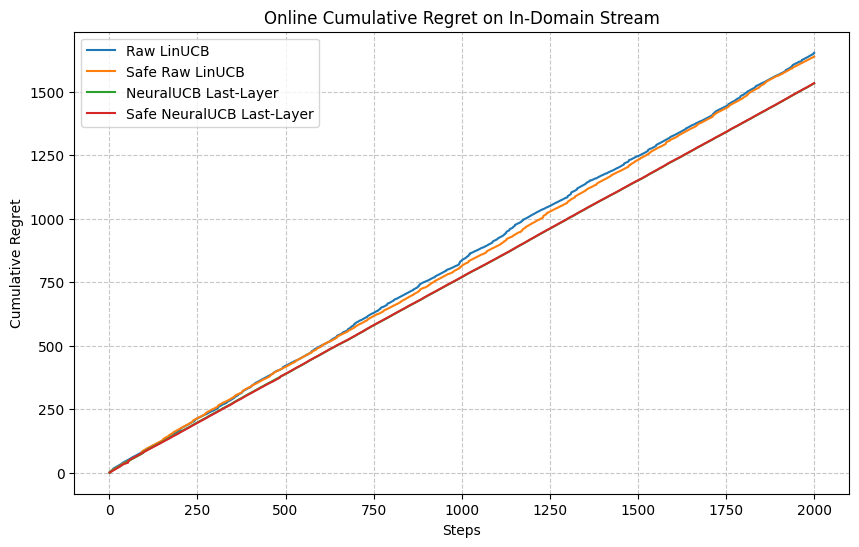

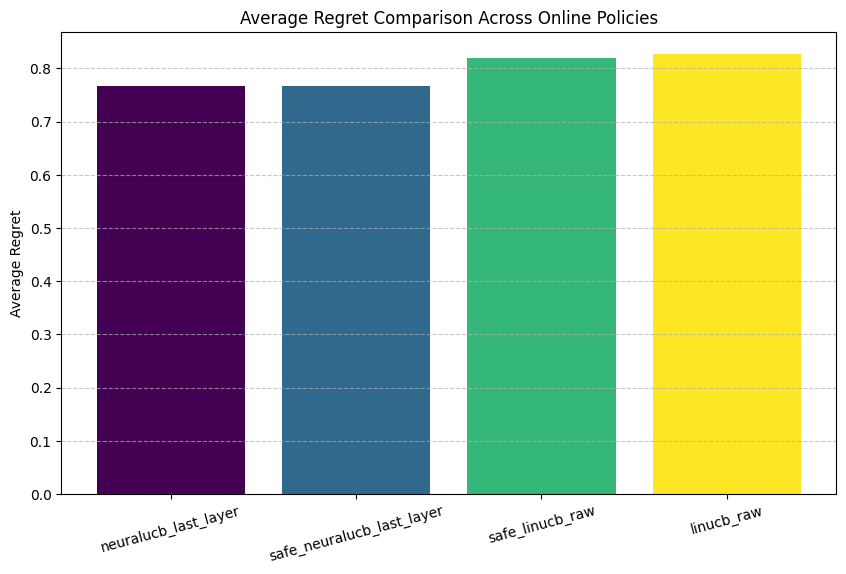

In [31]:
def policy_degradation_table(eval_results: pd.DataFrame, ood_results: pd.DataFrame) -> pd.DataFrame:
    df1 = eval_results.copy().set_index("policy")
    df2 = ood_results.copy().set_index("policy")
    
    merged = df1.join(df2, lsuffix="_eval", rsuffix="_ood")
    merged["regret_degradation"] = merged["avg_regret_ood"] - merged["avg_regret_eval"]
    
    return merged.reset_index().sort_values("regret_degradation")

unconstrained_degradation = policy_degradation_table(eval_results, ood_results)
safe_degradation = policy_degradation_table(safe_eval_results, safe_ood_results)

display(unconstrained_degradation)
display(safe_degradation)

online_summary = pd.DataFrame([
    {
        "policy": "linucb_raw",
        "cum_regret": float(linucb_trace.cum_regret.iloc[-1]),
        "avg_regret": float(linucb_trace.regret.mean()),
    },
    {
        "policy": "safe_linucb_raw",
        "cum_regret": float(safe_linucb_trace.cum_regret.iloc[-1]),
        "avg_regret": float(safe_linucb_trace.regret.mean()),
    },
    {
        "policy": "neuralucb_last_layer",
        "cum_regret": float(neuralucb_trace.cum_regret.iloc[-1]),
        "avg_regret": float(neuralucb_trace.regret.mean()),
    },
    {
        "policy": "safe_neuralucb_last_layer",
        "cum_regret": float(safe_neuralucb_trace.cum_regret.iloc[-1]),
        "avg_regret": float(safe_neuralucb_trace.regret.mean()),
    },
])
display(online_summary.sort_values("avg_regret"))

# add plots and final written report.

plt.figure(figsize=(10, 6))
plt.plot(linucb_trace["step"], linucb_trace["cum_regret"], label="Raw LinUCB")
plt.plot(safe_linucb_trace["step"], safe_linucb_trace["cum_regret"], label="Safe Raw LinUCB")
plt.plot(neuralucb_trace["step"], neuralucb_trace["cum_regret"], label="NeuralUCB Last-Layer")
plt.plot(safe_neuralucb_trace["step"], safe_neuralucb_trace["cum_regret"], label="Safe NeuralUCB Last-Layer")
plt.xlabel("Steps")
plt.ylabel("Cumulative Regret")
plt.title("Online Cumulative Regret on In-Domain Stream")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
bar_data = online_summary.sort_values("avg_regret")
plt.bar(bar_data["policy"], bar_data["avg_regret"], color=['#440154', '#31688e', '#35b779', '#fde725'])
plt.xticks(rotation=15)
plt.ylabel("Average Regret")
plt.title("Average Regret Comparison Across Online Policies")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Grading rubric

| Section | Points |
|---|---:|
| Real dataset loading, EDA, severity critique | 10 |
| Reward, oracle, regret | 10 |
| cost-sensitivity analysis | 10 |
| Logged bandit feedback and propensities | 10 |
| Reward model from chosen-action feedback | 15 |
| Fixed policies and uncertainty policies | 10 |
| safe exploration | 15 |
| Raw LinUCB | 10 |
| NeuralUCB-style LinUCB | 15 |
| Offline policy evaluation | 15 |
| calibration analysis | 15 |
| OOD stress analysis | 10 |
| Final safety/product discussion | 15 |


Total: 160 points.
